In [923]:
import openmeteo_requests
import requests
import pandas as pd
import requests_cache
from retry_requests import retry

from datetime import date, timedelta, datetime
import asyncio
from tqdm import tqdm

In [383]:
(date(*map(int,'2025-01-01'.split('-'))) - timedelta(1)).isoformat()

'2024-12-31'

In [755]:
(date(2026, 1, 2) - date(2025, 1, 1)).days

366

In [961]:
# ----------------------------------------------------------
# Импорт данных о загрязнении воздуха
# ----------------------------------------------------------

def get_pm25_daily_data(date):  # YYYY-MM-DD
    
    time_begin = date.isoformat() + ' 00:00:00'
    time_end = (date+timedelta(1)).isoformat() + ' 00:00:00'

    req = requests.get(
        'http://air.krasn.ru/api/2.0/data',
            params={
              'time_begin': time_begin,
              'time_end': time_end,
              'time_interval': 'hour',
              'projects': '9'
            }
    ).json()
    
    if req['status']['message'] != 'OK':
        raise Exception('Status is not ok')

    df = pd.DataFrame(req['data'])
    df['time'] = pd.to_datetime(df['time'])
    # df_date = pd.DataFrame({'time': pd.date_range(time_begin,time_end,freq='1h',inclusive='left')})
    # groups = []
    # for site, group in df.groupby('site'):
    #     sub = pd.merge(group, df_date, on='time', how='right')
    #     sub ['site'] = [site for _ in range(sub.shape[0])]
    #     groups.append(sub)
    
    # df = pd.concat(groups)
    df = df.rename(columns={'time': 'date'})
    
    df["date"] = (
        pd.to_datetime(df["date"])
        .dt.tz_localize("Asia/Krasnoyarsk")
        .dt.tz_convert("UTC")
    )
    
    return df[['date','site','pm25']].sort_values(by=['date','site']).reset_index(drop=True)

def get_pm25_data(start_date, end_date):
    start_date = date(*map(int,start_date.split('-')))
    end_date = date(*map(int,end_date.split('-')))
    delta = (end_date - start_date).days
    data = []
    for _ in tqdm(range(delta)):
        daily = get_pm25_daily_data(start_date)
        data.append(daily)
        start_date += timedelta(1)

    return pd.concat(data).reset_index(drop=True)

# ----------------------------------------------------------
# Импорт данных погоды
# ----------------------------------------------------------

def get_historical_weather_data(
        start_date: str, # "YYYY-MM-DD"
        end_date: str    # "YYYY-MM-DD"
        ) -> dict:

    # Учитываем, что данные open-meteo привязаны к временю Гринвича 
    # (7 часов данных находятся в предыдущем дне)
    start_date = (date(*map(int,start_date.split('-'))) - timedelta(1)).isoformat()
    
    cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
    retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
    openmeteo = openmeteo_requests.Client(session = retry_session)

    url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
    data_columns = [
        'temperature_2m',
        'relative_humidity_2m', 
        'pressure_msl',
        'surface_pressure',
        'temperature_80m',
        'temperature_120m',
        'temperature_180m',
        'wind_speed_10m',
        'wind_speed_80m',
        'wind_speed_120m',
        'wind_speed_180m',
        'wind_direction_10m',
        'wind_direction_80m',
        'wind_direction_120m',
        'wind_direction_180m',
        'precipitation', 
        'shortwave_radiation'
    ]
    params = {
        "latitude": 56.0267,
        "longitude": 92.9077,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": data_columns,
        "wind_speed_unit": "ms",
    }
    responses = openmeteo.weather_api(url, params = params)
    response = responses[0]
   
    # print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")
    
    hourly = response.Hourly()

    hourly_data = {
        "date": pd.date_range(
            start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
    		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
    		freq = pd.Timedelta(seconds = hourly.Interval()),
    		inclusive = "left"
        )
    }
    for i, col in enumerate(data_columns):
        hourly_data[col] = hourly.Variables(i).ValuesAsNumpy()
        
    hourly_dataframe = pd.DataFrame(data = hourly_data)
    df_date = pd.DataFrame({'date': pd.date_range(start_date,end_date,freq='1h',inclusive='left')})
    df_date['date'] = pd.to_datetime(df_date['date'], utc=True)

    df = pd.merge(hourly_dataframe, df_date,on='date', how='right')
    
    return df


# ----------------------------------------------------------
# Импорт и объединение данных
# ----------------------------------------------------------

def load_data(start_date, end_date):
    df_pollution = get_pm25_data(start_date, end_date)
    df_weather = get_historical_weather_data(start_date, end_date)

    df = pd.merge(df_pollution, df_weather, on='date')
    df['date'] = pd.to_datetime(df['date']).dt.tz_convert('Asia/Krasnoyarsk')
    
    df.to_csv(f'meteo_and_pollution_{int(datetime.now().timestamp())}.csv',index=False)

In [967]:
import os

In [969]:
PATH = os.getcwd()

In [981]:
os.path.dirname()

TypeError: dirname() missing 1 required positional argument: 'p'

In [963]:
load_data("2026-09-25",date.today().isoformat())

100%|███████████████████████████████████████████| 12/12 [00:04<00:00,  2.44it/s]


In [905]:
data.info()

,date,site,pm25,temperature_2m,relative_humidity_2m,pressure_msl,surface_pressure,temperature_80m,temperature_120m,temperature_180m,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_speed_180m,wind_direction_10m,wind_direction_80m,wind_direction_120m,wind_direction_180m,precipitation,shortwave_radiation
0,2026-09-25 00:00:00+07:00,3837,9.2,7.7,86.864166,1018.900024,996.878662,13.8920,13.7920,13.192000,1.250000,1.978985,2.072392,2.214059,196.260284,232.001205,232.001205,246.297348,0.0,0.0
1,2026-09-25 00:00:00+07:00,3841,13.8,7.7,86.864166,1018.900024,996.878662,13.8920,13.7920,13.192000,1.250000,1.978985,2.072392,2.214059,196.260284,232.001205,232.001205,246.297348,0.0,0.0
2,2026-09-25 00:00:00+07:00,3842,14.1,7.7,86.864166,1018.900024,996.878662,13.8920,13.7920,13.192000,1.250000,1.978985,2.072392,2.214059,196.260284,232.001205,232.001205,246.297348,0.0,0.0
3,2026-09-25 00:00:00+07:00,3843,39.0,7.7,86.864166,1018.900024,996.878662,13.8920,13.7920,13.192000,1.250000,1.978985,2.072392,2.214059,196.260284,232.001205,232.001205,246.297348,0.0,0.0
4,2026-09-25 00:00:00+07:00,3846,10.5,7.7,86.864166,1018.900024,996.878662,13.8920,13.7920,13.192000,1.250000,1.978985,2.072392,2.214059,196.260284,232.001205,232.001205,246.297348,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5467,2026-10-06 23:00:00+07:00,3915,82.0,6.2,64.738922,1017.500000,995.392456,10.3325,10.2325,9.632501,2.400521,6.253355,6.548507,9.284547,181.193466,194.902695,194.902695,202.878098,0.0,0.0
5468,2026-10-06 23:00:00+07:00,4227,NaN,6.2,64.738922,1017.500000,995.392456,10.3325,10.2325,9.632501,2.400521,6.253355,6.548507,9.284547,181.193466,194.902695,194.902695,202.878098,0.0,0.0
5469,2026-10-06 23:00:00+07:00,4228,10.9,6.2,64.738922,1017.500000,995.392456,10.3325,10.2325,9.632501,2.400521,6.253355,6.548507,9.284547,181.193466,194.902695,194.902695,202.878098,0.0,0.0
5470,2026-10-06 23:00:00+07:00,4324,5.2,6.2,64.738922,1017.500000,995.392456,10.3325,10.2325,9.632501,2.400521,6.253355,6.548507,9.284547,181.193466,194.902695,194.902695,202.878098,0.0,0.0


In [888]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64680 entries, 0 to 64679
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype                           
---  ------                --------------  -----                           
 0   date                  64680 non-null  datetime64[ns, Asia/Krasnoyarsk]
 1   site                  64680 non-null  int64                           
 2   pm25                  64005 non-null  float64                         
 3   temperature_2m        64680 non-null  float32                         
 4   relative_humidity_2m  64680 non-null  float32                         
 5   pressure_msl          64680 non-null  float32                         
 6   surface_pressure      64680 non-null  float32                         
 7   temperature_80m       64680 non-null  float32                         
 8   temperature_120m      64680 non-null  float32                         
 9   temperature_180m      64680 non-null  float32     

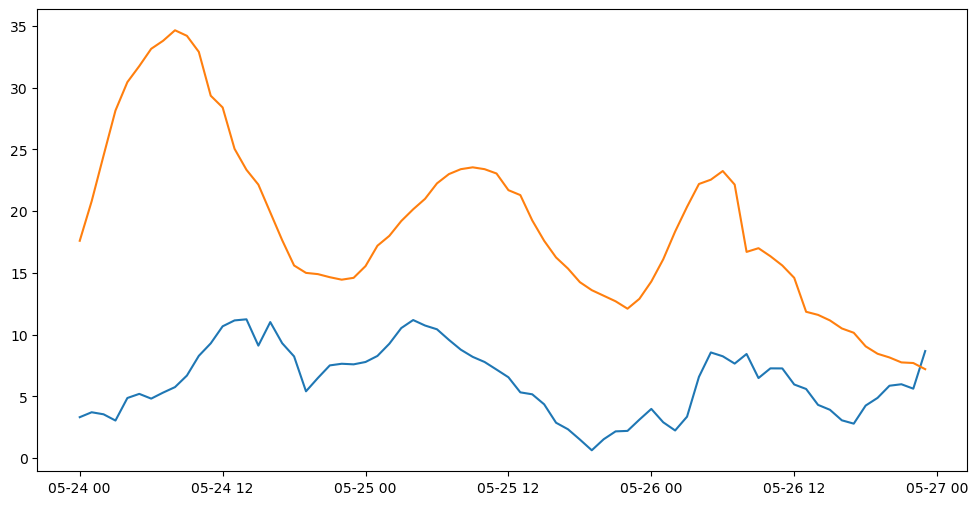

In [856]:
plt.figure(figsize=(12,6))
plt.plot(data_w['date'],data_w['wind_speed_180m'])
plt.plot(data_w['date'],data_w['temperature_2m'])

In [858]:
data_w

,date,temperature_2m,relative_humidity_2m,pressure_msl,surface_pressure,temperature_80m,temperature_120m,temperature_180m,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_speed_180m,wind_direction_10m,wind_direction_80m,wind_direction_120m,wind_direction_180m,precipitation,shortwave_radiation
0,2025-05-24 00:00:00+00:00,17.600000,44.927521,1006.599976,985.576111,20.292000,20.992001,21.692001,0.650000,1.940814,2.032418,3.312099,157.380096,151.504456,151.504456,151.113510,0.0,191.0
1,2025-05-24 01:00:00+00:00,20.799999,38.368092,1006.700012,985.900208,20.792000,21.391998,22.091999,0.921954,1.619994,1.696456,3.712142,102.528801,133.781204,133.781204,152.744751,0.0,329.0
2,2025-05-24 02:00:00+00:00,24.500000,29.610188,1006.000000,985.469666,22.891998,22.192001,22.391998,1.277693,1.881158,1.969947,3.546829,120.579147,126.573120,126.573120,158.498505,0.0,453.0
3,2025-05-24 03:00:00+00:00,28.150000,20.978075,1005.099976,984.833557,24.992001,24.292000,23.492001,1.960230,2.826573,2.959985,3.041381,127.746872,133.602890,133.602890,152.592514,0.0,582.0
4,2025-05-24 04:00:00+00:00,30.450001,15.713480,1004.599976,984.495361,26.591999,25.792000,24.992001,2.616295,3.706670,3.881621,4.866210,153.924698,155.119659,155.119659,170.537750,0.0,620.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2025-05-26 19:00:00+00:00,8.450000,81.695786,1004.400024,982.749268,8.792000,8.292000,7.592000,2.088660,4.449499,4.659511,4.876474,227.910904,241.189301,241.189301,241.858490,0.0,0.0
68,2025-05-26 20:00:00+00:00,8.150000,82.798317,1004.400024,982.726440,8.392000,7.892000,7.192000,1.780449,4.082038,4.274706,5.860034,218.157272,236.689362,236.689362,244.746872,0.0,0.0
69,2025-05-26 21:00:00+00:00,7.750000,83.907539,1004.299988,982.598206,8.092000,7.592000,6.892000,1.530523,3.960670,4.147610,5.980803,218.367523,235.527725,235.527725,249.443863,0.0,0.0
70,2025-05-26 22:00:00+00:00,7.700000,82.741859,1005.000000,983.279053,7.792000,7.292000,6.492000,3.118493,5.532975,5.794126,5.622277,257.969421,264.440155,264.440155,264.897919,0.0,8.0


In [846]:
data_p.tail(50)

,time,site,pm25
958,2025-05-26 21:00:00,4363,5.2
959,2025-05-26 21:00:00,3849,1.1
960,2025-05-26 21:00:00,3843,2.5
961,2025-05-26 21:00:00,3853,1.5
962,2025-05-26 21:00:00,4227,1.7
963,2025-05-26 21:00:00,3855,2.5
964,2025-05-26 21:00:00,4228,1.7
965,2025-05-26 21:00:00,3857,2.5
966,2025-05-26 22:00:00,4325,3.2
967,2025-05-26 22:00:00,3837,2.9


In [834]:
data_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    504 non-null    datetime64[ns]
 1   site    504 non-null    int64         
 2   pm25    504 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 11.9 KB


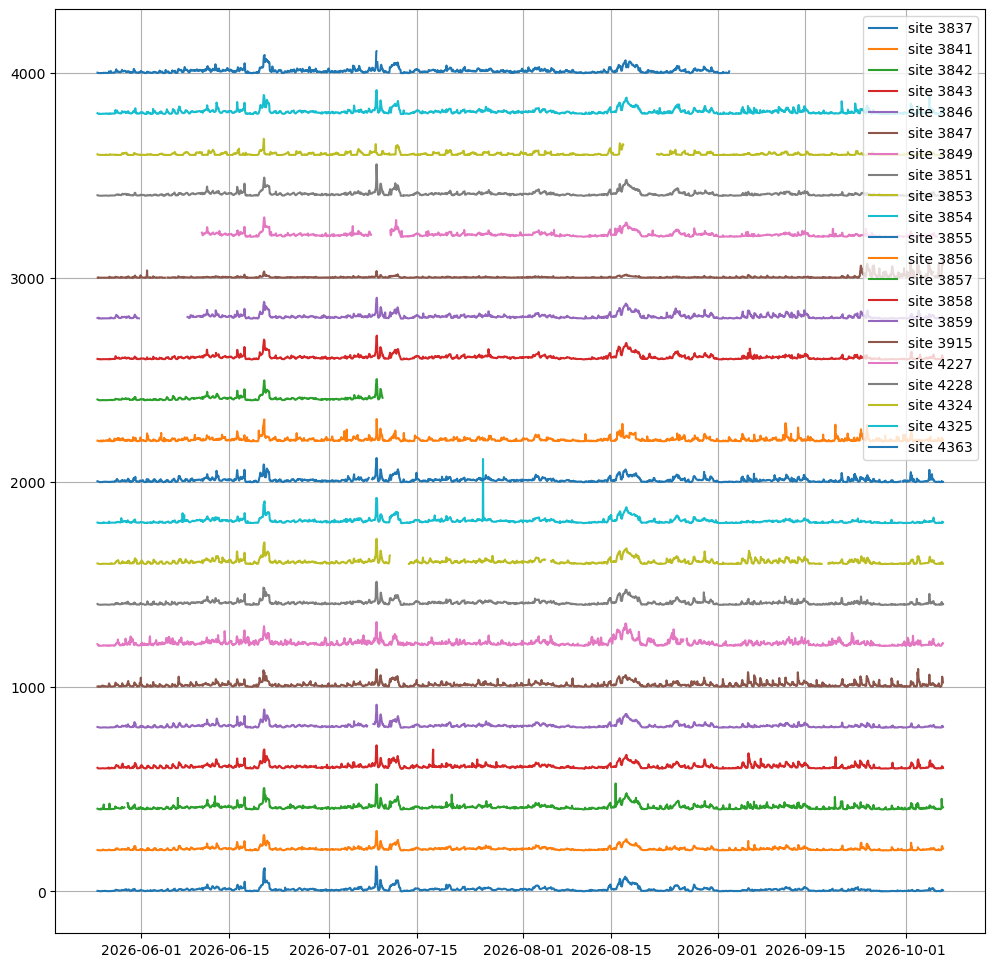

In [892]:
plt.figure(figsize=(12,12))
df_date = pd.DataFrame({'date': pd.date_range(data['date'].min(),data['date'].max(),freq='1h')})
d = 0
for site, group in data.groupby('site'):
    sub_df = pd.merge(df_date,group,on='date',how='left')
    plt.plot(sub_df['date'],sub_df['pm25'] + d, label=f"site {site}")
    d += 200
plt.legend()
plt.grid()
plt.show()

In [721]:
df_date

,time
0,2022-01-25 00:00:00
1,2022-01-25 01:00:00
2,2022-01-25 02:00:00
3,2022-01-25 03:00:00
4,2022-01-25 04:00:00
...,...
26324,2025-01-25 20:00:00
26325,2025-01-25 21:00:00
26326,2025-01-25 22:00:00
26327,2025-01-25 23:00:00


In [693]:
data_p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500251 entries, 0 to 26328
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype              
---  ------  --------------   -----              
 0   time    500251 non-null  datetime64[ns, UTC]
 1   site    500251 non-null  int64              
 2   pm25    9967 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(1), int64(1)
memory usage: 15.3 MB


In [696]:
data_p['site'].unique().shape

(19,)

In [698]:
data_p

,time,site,pm25
0,2022-01-24 17:00:00+00:00,3837,8.4
0,2022-01-24 17:00:00+00:00,3842,18.8
0,2022-01-24 17:00:00+00:00,3841,22.9
0,2022-01-24 17:00:00+00:00,3915,13.7
0,2022-01-24 17:00:00+00:00,3843,9.7
...,...,...,...
26328,2025-01-25 17:00:00+00:00,3837,NaN
26328,2025-01-25 17:00:00+00:00,3851,NaN
26328,2025-01-25 17:00:00+00:00,3856,NaN
26328,2025-01-25 17:00:00+00:00,3841,NaN


In [700]:
data_p[data_p['site']==3852]

,time,site,pm25
0,2022-01-24 17:00:00+00:00,3852,15.6
1,2022-01-24 18:00:00+00:00,3852,12.8
2,2022-01-24 19:00:00+00:00,3852,12.2
3,2022-01-24 20:00:00+00:00,3852,12.9
4,2022-01-24 21:00:00+00:00,3852,11.5
...,...,...,...
26324,2025-01-25 13:00:00+00:00,3852,NaN
26325,2025-01-25 14:00:00+00:00,3852,NaN
26326,2025-01-25 15:00:00+00:00,3852,NaN
26327,2025-01-25 16:00:00+00:00,3852,NaN


In [477]:
df = pd.merge(
    data_w,
    data_p,
    left_on="date",
    right_on="time",
    how="inner"
)

In [479]:
df['date'] = df['date'].dt.tz_convert('Asia/Krasnoyarsk')
df

,date,temperature_2m,relative_humidity_2m,pressure_msl,surface_pressure,temperature_80m,temperature_120m,temperature_180m,wind_speed_10m,wind_speed_80m,...,wind_speed_180m,wind_direction_10m,wind_direction_80m,wind_direction_120m,wind_direction_180m,precipitation,shortwave_radiation,time,site,pm25
0,2025-01-25 00:00:00+07:00,-22.5,59.178757,1057.699951,1032.125732,-21.908001,-22.507999,-23.208,3.592005,7.271828,...,7.359348,218.784378,224.185516,224.185516,222.797379,0.0,0.0,2025-01-24 17:00:00+00:00,3837,1.7
1,2025-01-25 00:00:00+07:00,-22.5,59.178757,1057.699951,1032.125732,-21.908001,-22.507999,-23.208,3.592005,7.271828,...,7.359348,218.784378,224.185516,224.185516,222.797379,0.0,0.0,2025-01-24 17:00:00+00:00,3841,10.4
2,2025-01-25 00:00:00+07:00,-22.5,59.178757,1057.699951,1032.125732,-21.908001,-22.507999,-23.208,3.592005,7.271828,...,7.359348,218.784378,224.185516,224.185516,222.797379,0.0,0.0,2025-01-24 17:00:00+00:00,3842,21.4
3,2025-01-25 00:00:00+07:00,-22.5,59.178757,1057.699951,1032.125732,-21.908001,-22.507999,-23.208,3.592005,7.271828,...,7.359348,218.784378,224.185516,224.185516,222.797379,0.0,0.0,2025-01-24 17:00:00+00:00,3843,1.6
4,2025-01-25 00:00:00+07:00,-22.5,59.178757,1057.699951,1032.125732,-21.908001,-22.507999,-23.208,3.592005,7.271828,...,7.359348,218.784378,224.185516,224.185516,222.797379,0.0,0.0,2025-01-24 17:00:00+00:00,3846,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1051,2025-01-26 23:00:00+07:00,-11.9,74.895782,1033.400024,1009.413147,-12.108000,-12.708000,-13.508,2.934706,5.441868,...,9.454100,246.929565,250.104477,250.104477,259.640991,0.1,0.0,2025-01-26 16:00:00+00:00,4228,6.0
1052,2025-01-26 23:00:00+07:00,-11.9,74.895782,1033.400024,1009.413147,-12.108000,-12.708000,-13.508,2.934706,5.441868,...,9.454100,246.929565,250.104477,250.104477,259.640991,0.1,0.0,2025-01-26 16:00:00+00:00,4324,2.6
1053,2025-01-26 23:00:00+07:00,-11.9,74.895782,1033.400024,1009.413147,-12.108000,-12.708000,-13.508,2.934706,5.441868,...,9.454100,246.929565,250.104477,250.104477,259.640991,0.1,0.0,2025-01-26 16:00:00+00:00,4325,10.4
1054,2025-01-26 23:00:00+07:00,-11.9,74.895782,1033.400024,1009.413147,-12.108000,-12.708000,-13.508,2.934706,5.441868,...,9.454100,246.929565,250.104477,250.104477,259.640991,0.1,0.0,2025-01-26 16:00:00+00:00,4363,2.9


In [483]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype                           
---  ------                --------------  -----                           
 0   date                  1056 non-null   datetime64[ns, Asia/Krasnoyarsk]
 1   temperature_2m        1056 non-null   float32                         
 2   relative_humidity_2m  1056 non-null   float32                         
 3   pressure_msl          1056 non-null   float32                         
 4   surface_pressure      1056 non-null   float32                         
 5   temperature_80m       1056 non-null   float32                         
 6   temperature_120m      1056 non-null   float32                         
 7   temperature_180m      1056 non-null   float32                         
 8   wind_speed_10m        1056 non-null   float32                         
 9   wind_speed_80m        1056 non-null   float32       

In [217]:
import matplotlib.pyplot as plt

<Axes: >

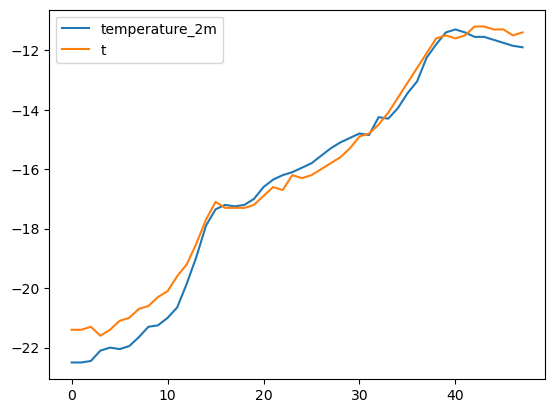

In [428]:
df[['temperature_2m','t']].plot()